1.
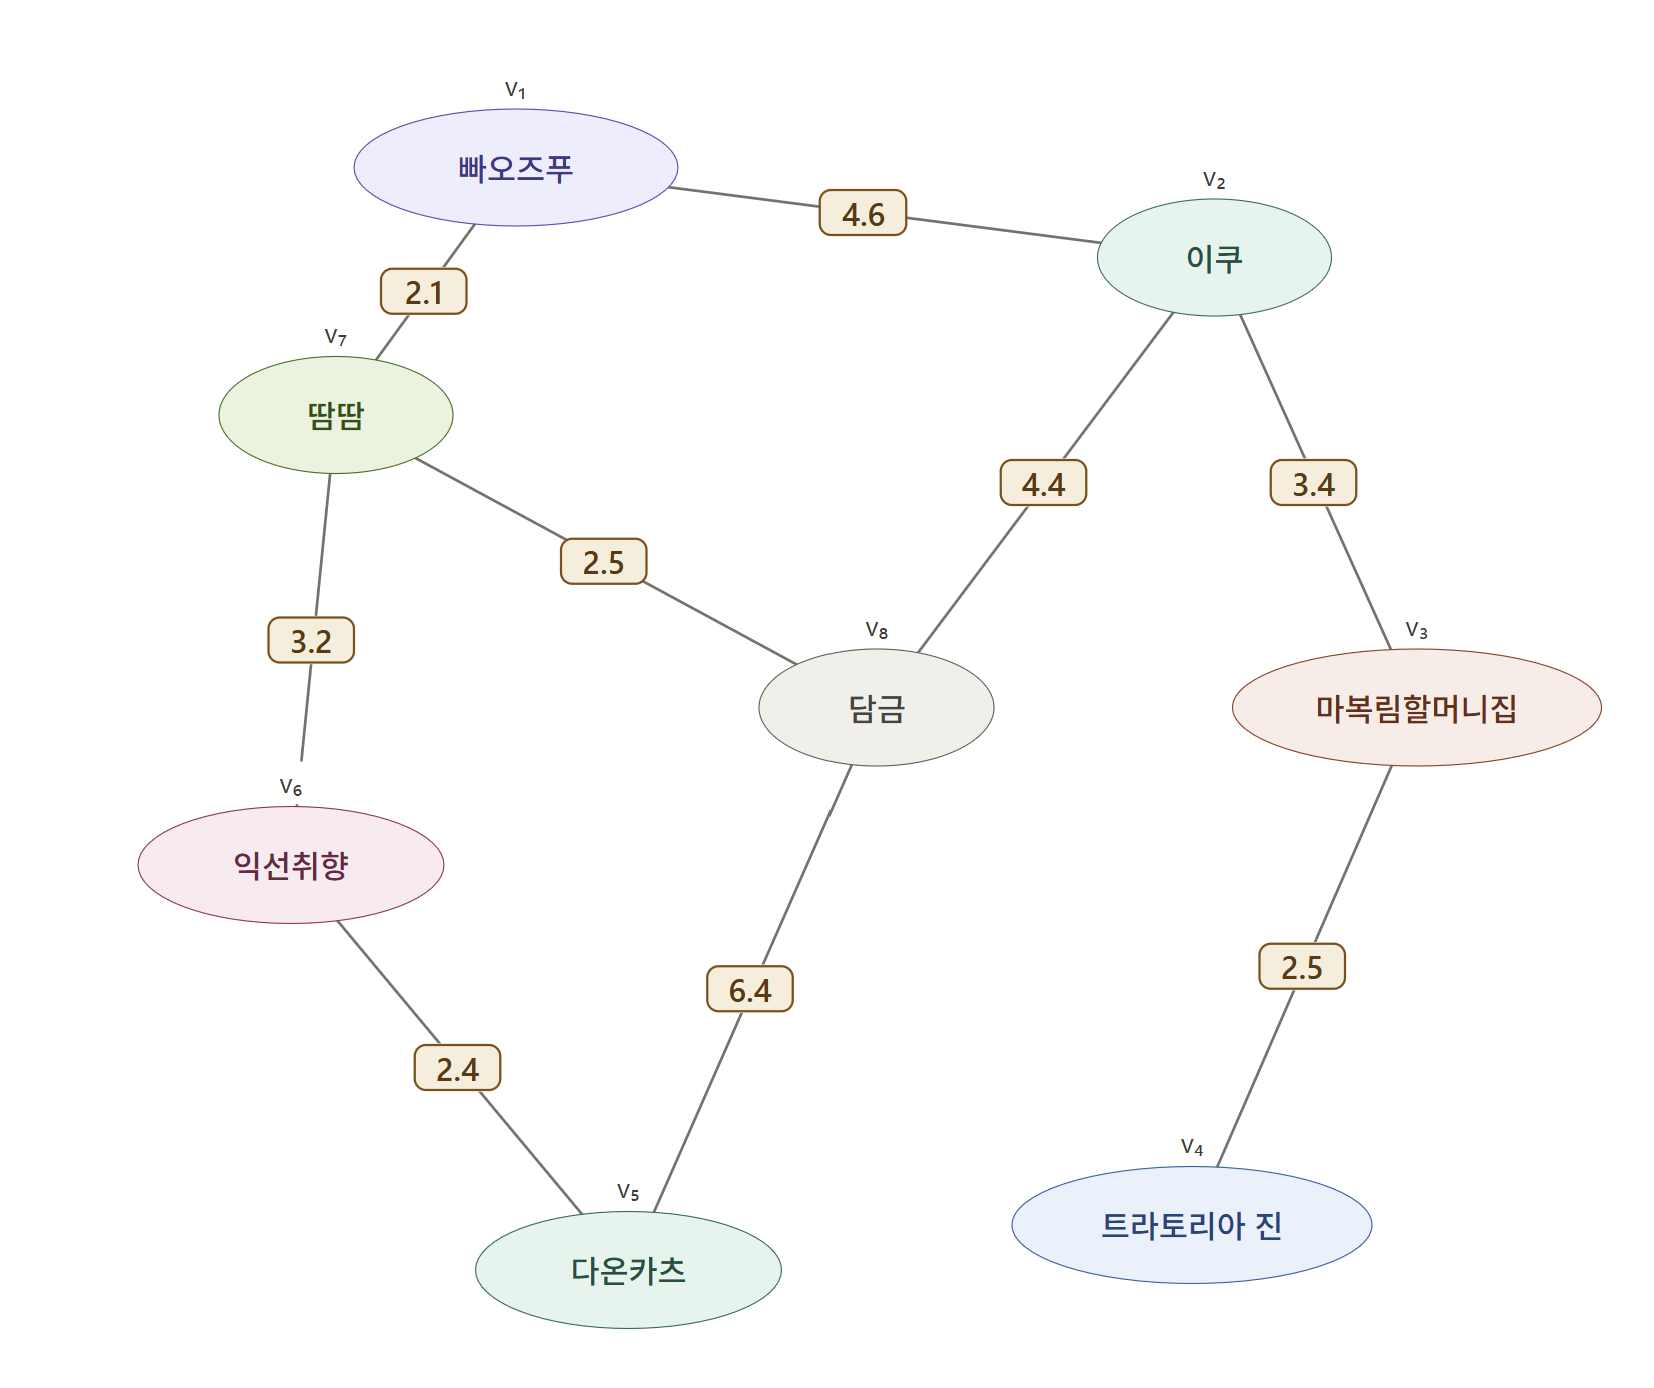

2-(1) DFS 알고리즘 코드

In [ ]:
# 그래프를 딕셔너리로 표현 (정점 번호: [(연결된 정점, 가중치), ...])
graph = {
    1: [(2, 4.6), (7, 2.1)],
    2: [(1, 4.6), (3, 3.4), (8, 4.4)],
    3: [(2, 3.4), (4, 2.5)],
    4: [(3, 2.5)],
    5: [(6, 2.4), (8, 6.4)],
    6: [(5, 2.4), (7, 3.2)],
    7: [(1, 2.1), (6, 3.2), (8, 2.5)],
    8: [(2, 4.4), (5, 6.4), (7, 2.5)]
}

restaurant_names = {
    1: "빠오즈푸", 2: "이쿠", 3: "마복림할머니집", 4: "트라토리아 진",
    5: "다온카츠", 6: "익선취향", 7: "땀땀", 8: "담금"
}

# 방문 여부를 추적할 집합 (Set)
visited = set()

def dfs(current):
    # 현재 정점 방문 처리
    visited.add(current)
    print(f"V{current} ({restaurant_names[current]}) 방문")

    # 인접 정점 정렬 (번호가 작은 순서대로 방문)
    # sorted()를 통해 연결된 정점들의 번호를 기준으로 정렬합니다.
    neighbors = sorted(graph[current], key=lambda x: x[0])

    for next_node, weight in neighbors:
        if next_node not in visited:
            print(f"  -> [이동] 가중치 {weight}을(를) 거쳐 V{next_node} 방향으로 이동")
            dfs(next_node)

# 탐색 시작
print("===== DFS 음식점 탐색 시작 (출발: V1 빠오즈푸) =====\n")
dfs(1)

2-(2) BFS 알고리즘 코드

In [ ]:
from collections import deque


graph = {
    1: [(2, 4.6), (7, 2.1)],
    2: [(1, 4.6), (3, 3.4), (8, 4.4)],
    3: [(2, 3.4), (4, 2.5)],
    4: [(3, 2.5)],
    5: [(6, 2.4), (8, 6.4)],
    6: [(5, 2.4), (7, 3.2)],
    7: [(1, 2.1), (6, 3.2), (8, 2.5)],
    8: [(2, 4.4), (5, 6.4), (7, 2.5)]
}

restaurant_names = {
    1: "빠오즈푸", 2: "이쿠", 3: "마복림할머니집", 4: "트라토리아 진",
    5: "다온카츠", 6: "익선취향", 7: "땀땀", 8: "담금"
}

def bfs(start_node):
    visited = set()
    queue = deque([start_node])

    # 시작점 방문 처리
    visited.add(start_node)

    print(f"===== BFS 음식점 탐색 시작 (출발: V{start_node} {restaurant_names[start_node]}) =====\n")

    while queue:
        current = queue.popleft()
        print(f"방문 중: V{current} ({restaurant_names[current]})")

        # 인접 정점 정렬 (번호가 작은 순서대로 큐에 삽입)
        neighbors = sorted(graph[current], key=lambda x: x[0])

        for next_node, weight in neighbors:
            if next_node not in visited:
                visited.add(next_node)
                queue.append(next_node)
                print(f"  -> [큐에 추가] 가중치 {weight}을(를) 거쳐 V{next_node} 발견")

# 탐색 시작
bfs(1)

2-(3) 프림 알고리즘 코드

In [ ]:
import heapq

# 그래프 데이터
graph = {
    1: [(2, 4.6), (7, 2.1)],
    2: [(1, 4.6), (3, 3.4), (8, 4.4)],
    3: [(2, 3.4), (4, 2.5)],
    4: [(3, 2.5)],
    5: [(6, 2.4), (8, 6.4)],
    6: [(5, 2.4), (7, 3.2)],
    7: [(1, 2.1), (6, 3.2), (8, 2.5)],
    8: [(2, 4.4), (5, 6.4), (7, 2.5)]
}

restaurant_names = {
    1: "빠오즈푸", 2: "이쿠", 3: "마복림할머니집", 4: "트라토리아 진",
    5: "다온카츠", 6: "익선취향", 7: "땀땀", 8: "담금"
}

def prim(start_node):
    # 최소 힙: (가중치, 현재정점, 다음정점)
    mst = []
    visited = {start_node}
    edges = [
        (weight, start_node, to_node)
        for to_node, weight in graph[start_node]
    ]
    heapq.heapify(edges)

    total_weight = 0

    print(f"===== 프림 알고리즘 시작 (출발: V{start_node} {restaurant_names[start_node]}) =====\n")

    while edges:
        weight, frm, to = heapq.heappop(edges)

        if to not in visited:
            visited.add(to)
            mst.append((frm, to, weight))
            total_weight += weight
            print(f"연결 추가: V{frm} -> V{to} (가중치: {weight})")

            # 다음으로 갈 수 있는 간선들을 힙에 추가
            for next_node, next_weight in graph[to]:
                if next_node not in visited:
                    heapq.heappush(edges, (next_weight, to, next_node))

    print(f"\n최소 신장 트리(MST) 총 가중치: {total_weight:.1f}")
    return mst

# 실행
prim(1)

2-(4) 크루스칼 알고리즘 코드

In [ ]:
# 1. 모든 간선 정보를 리스트로 변환하고 가중치(x[2]) 기준 오름차순 정렬
edges = [
    (1, 2, 4.6), (1, 7, 2.1), (2, 3, 3.4), (2, 8, 4.4),
    (3, 4, 2.5), (5, 6, 2.4), (5, 8, 6.4), (6, 7, 3.2), (7, 8, 2.5)
]
edges.sort(key=lambda x: x[2])  # 가중치 기준 정렬

# 2. Union-Find를 위한 부모 테이블 초기화
parent = {i: i for i in range(1, 9)}

def find(i):
    if parent[i] == i:
        return i
    parent[i] = find(parent[i])  # 경로 압축(Path Compression)
    return parent[i]

def union(i, j):
    root_i = find(i)
    root_j = find(j)
    if root_i != root_j:
        parent[root_i] = root_j
        return True
    return False

# 3. 크루스칼 알고리즘 실행
mst = []
total_weight = 0

print("===== 크루스칼 알고리즘 시작 (간선 정렬 후 연결) =====\n")

for u, v, weight in edges:
    # 두 정점의 부모가 다르면 사이클이 형성되지 않으므로 연결
    if union(u, v):
        mst.append((u, v, weight))
        total_weight += weight
        print(f"간선 선택: V{u} - V{v} (가중치: {weight})")

print(f"\n최소 신장 트리(MST) 총 가중치: {total_weight:.1f}")